# Homework 6: N-Gram Language Models with the Brown Corpus

## Due: Midnight on October 12th @ Midnight (with 2-hour grace period) and worth 85 points.

## As announced, I'll not start to count late days until midnight on 10/13 (with same grace period).

In this assignment you’ll practice **probabilistic language modeling (PLM)** by building N-Gram models that generate text. Along the way, you’ll develop the core pieces of a language model: estimating probabilities, calculating sentence likelihoods, and generating text with different strategies. The goal is to understand *how simple statistical models can produce coherent language*, and to explore refinements that make them more expressive.

### Learning Objectives

* Build and compare **unigram, bigram, and trigram** language models.
* Calculate **word and sentence probabilities** (in log-space) and use them to measure **perplexity**.
* Implement **probability-based generation** methods, including temperature-scaled sampling.
* Explore **beam search** as a way to generate higher-quality sentences.

### The four problems (high level)

1. **Problem 1 — N-Gram probabilities:**
   Build unigram, bigram, and trigram models. Compute next-word probabilities in log space to avoid numerical underflow.

2. **Problem 2 — Sentence probability & perplexity:**
   Define sentence probability, normalize for sentence length, and calculate perplexity as a measure of model quality.

3. **Problem 3 — Controlled generation:**
   Implement temperature-controlled sampling to vary randomness in generated sentences. Compare low vs. high temperatures.

4. **Problem 4 — Beam search:**
   Use perplexity to guide **beam search**, keeping track of the most likely candidate sentences at each step, and compare outputs to greedy generation.

By the end, you’ll have a working N-Gram generator capable of producing reasonable and a solid understanding of how early probabilistic approaches to NLP laid the foundation for modern deep learning methods.



### Recommended Workflow (Must Read!)

One of the most important skills in machine learning is following a **disciplined workflow** when developing complex code. The basic idea is simple:

1. **Start small:** Write and test your code using a tiny subset of your dataset.
2. **Inspect your results:** Print out and examine intermediate outputs to verify that each step behaves as expected.
3. **Iterate and tune:** Adjust hyperparameters and continue testing, gradually increasing the subset size as needed.
4. **Scale up:** Once you are confident your code is bug-free and your hyperparameters are roughly correct, run it on the **full dataset** to obtain your final results.

If you don’t have sufficient computing resources for a full run, use **as large a subset as practical** — provided you’ve begun early enough to allow for multiple iterations.


To help you follow this workflow in this homework, I’ve included a variable `num_sentences` that controls how many sentences are used from the shuffled Brown Corpus.

I recommend the following progression:

* **Step 1:** Begin with `num_sentences = 10` to debug and print out intermediate data structures (such as dictionaries) to confirm that your code works as expected.
* **Step 2:** Increase to `num_sentences = 100` to verify correctness and complete most of the homework efficiently.
* **Step 3:** Finally, if possible, run with the full dataset (`num_sentences = 57_340`), or as large a subset as your resources allow, to answer the graded questions.


There are 9 problems in this homework, each worth 9 points each, and you get 4 points free if you otherwise complete the homework.

#### Useful Imports (add more as needed)

In [3]:
import math
import re
import string
import random
import spacy
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt
from collections import Counter

random.seed(42)

In [4]:
'''
Reconstruct a human-readable sentence from tokens.
- Capitalize the first token (after removing <s>).
- Attach any token in string.punctuation with no preceding space.
- Attach tokens starting with an apostrophe (e.g., "'s", "'ll") with no space.
- Capitalize standalone 'i' and 'god' wherever they appear.
- If the last token is '.', '?', or '!', attach it without a space.
- Ignore boundary markers <s> and </s> if present.
Returns the sentence string and also prints it depending on flag parameter.
'''

def print_sentence(tokens, do_print=True):

    if not tokens:
        print("")
        return ""

    # Drop boundary markers if present
    start = 1 if tokens and tokens[0] == "<s>" else 0
    end = -1 if tokens and tokens[-1] == "</s>" else len(tokens)
    core = tokens[start:end]

    if not core:
        print("")
        return ""

    # Capitalize first token
    out = core[0].capitalize()

    # Process remaining tokens with spacing rules
    for i, t in enumerate(core[1:], start=1):
        is_last = (i == len(core) - 1)

        # Last-token punctuation rule
        if is_last and t in {".", "?", "!"}:
            out += t
            continue

        # General punctuation attaches with no space (e.g., ',', ':', ';', ')', etc.)
        if t in string.punctuation:
            out += t
            continue

        # Apostrophe-start tokens like "'s", "'d", "'ll"
        if t.startswith("'"):
            out += t
            continue

        # Capitalize special standalone words
        if t.lower() in {"i", "god"}:
            out += " " + t.capitalize()
            continue

        # Default: add a space before normal words
        out += " " + t

    if do_print:
        print(out)
    return out


### Read in the list of all sentences in the Brown Corpus and process using SPaCy.

In [5]:
# Must do this the first time to get the Natural Language ToolKit

!pip install nltk

In [6]:
import nltk
from nltk.corpus import brown
import spacy

nltk.download('brown')

# Get all Brown corpus sentences as raw text
# Brown is organized into categories, we flatten it into one list of sentences and shuffle
# so we can create a shorter list for testing

brown_texts = [" ".join(sent) for sent in brown.sents()]

random.shuffle(brown_texts)

# Brown has 57_340 sentences, set `num_sentences` to 1000 or smaller for testing

num_sentences = 57_340
#num_sentences = 1000                           # <<<<<=====    Here is where you can change the size of the dataset

brown_texts = brown_texts[:num_sentences]

# Load spaCy English pipeline
nlp = spacy.load("en_core_web_sm")

# Process with spaCy: tokenize + sentencize
docs = list(nlp.pipe(brown_texts, disable=["ner", "tagger", "parser"]))

# Each doc is one sentence; extract tokens and add beginning and ending tokens <s> ... </s>
tokenized_sentences = [ ['<s>'] + [token.text.lower() for token in doc if not token.is_space] + ['</s>'] for doc in docs ]

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
/usr/local/lib/python3.12/dist-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


#### If you have trouble downloading this...


I have uploaded a file `brown_sentences.txt` to a Google Drive folder which anyone with the link can read, just
uncomment the code in the next cell and run it:

In [7]:
'''
import re, requests, random, spacy

# Paste the shared Drive link (no need to change anything else)
link = "https://drive.google.com/file/d/1f_BkNDF0ny11Tn4D4jsOoXhgPSUCHKlf/view?usp=drive_link"

# --- Convert to direct download URL ---
def get_direct_download_url(link):
    match = re.search(r"/d/([a-zA-Z0-9_-]+)", link) or re.search(r"id=([a-zA-Z0-9_-]+)", link)
    if not match:
        raise ValueError("Could not extract file ID from the link.")
    file_id = match.group(1)
    return f"https://drive.google.com/uc?export=download&id={file_id}"

url = get_direct_download_url(link)

# --- Download and prepare the text ---
response = requests.get(url)
lines = response.text.strip().split("\n")

random.shuffle(lines)


# Etc as before
'''

'\nimport re, requests, random, spacy\n\n# Paste the shared Drive link (no need to change anything else)\nlink = "https://drive.google.com/file/d/1f_BkNDF0ny11Tn4D4jsOoXhgPSUCHKlf/view?usp=drive_link"\n\n# --- Convert to direct download URL ---\ndef get_direct_download_url(link):\n    match = re.search(r"/d/([a-zA-Z0-9_-]+)", link) or re.search(r"id=([a-zA-Z0-9_-]+)", link)\n    if not match:\n        raise ValueError("Could not extract file ID from the link.")\n    file_id = match.group(1)\n    return f"https://drive.google.com/uc?export=download&id={file_id}"\n\nurl = get_direct_download_url(link)\n\n# --- Download and prepare the text ---\nresponse = requests.get(url)\nlines = response.text.strip().split("\n")\n\nrandom.shuffle(lines)\n\n\n# Etc as before\n'

In [8]:
print("Number of sentences:", len(tokenized_sentences))
print("First sentence:      ",end='')
print_sentence(tokenized_sentences[0])
print("Tokenized sentence: ",end='')
print(tokenized_sentences[0])

Number of sentences: 57340
First sentence:      He let her tell him all about the church.
Tokenized sentence: ['<s>', 'he', 'let', 'her', 'tell', 'him', 'all', 'about', 'the', 'church', '.', '</s>']


### A Little EDA....

In [6]:
# Flatten tokens (exclude spaces)
all_tokens = [tok.text.lower() for sent in docs for tok in sent if not tok.is_space]

# Define "word": alphabetic, or alphabetic after removing internal apostrophes
def is_word(tok):
    s = tok.text
    return s.isalpha() or s.replace("'", "").isalpha()

# Extract words using the definition above
words = [
    tok.text.lower()
    for sent in docs
    for tok in sent
    if not tok.is_space and is_word(tok)
]

# Counts
num_chars = sum(len(s) for s in brown_texts)   # or len(text) if you started from one big text
num_tokens = len(all_tokens)
num_unique_tokens = len(set(all_tokens))
num_sentences = len(docs)
num_words = len(words)
num_unique_words = len(set(words))

print(f"Total number of characters in the text: {num_chars:,}")
print(f"Total number of tokens:    {num_tokens:,}")
print(f"Number of unique tokens:   {num_unique_tokens:,}")
print(f"Total number of sentences: {num_sentences:,}")
print(f"Total number of words:     {num_words:,}")
print(f"Number of unique words:    {num_unique_words:,}")

# Frequencies
word_counts = Counter(words)
most_common_words = word_counts.most_common()

# Top 10
print("\nTop 10 words:")
for token, freq in most_common_words[:10]:
    print(f"{token:<15}: {freq:,}")

# Bottom 10
print("\nBottom 10 words:")
for token, freq in most_common_words[-10:]:
    print(f"{token:<15}: {freq:,}")

Total number of characters in the text: 6,069,734
Total number of tokens:    1,198,833
Number of unique tokens:   43,320
Total number of sentences: 57,340
Total number of words:     1,017,681
Number of unique words:    41,455

Top 10 words:
the            : 70,003
of             : 36,473
and            : 28,916
to             : 26,241
a              : 23,259
in             : 21,419
that           : 10,789
is             : 10,206
was            : 9,969
he             : 9,801

Bottom 10 words:
sedentary      : 1
spellbound     : 1
hydro          : 1
keepers        : 1
pompadour      : 1
overland       : 1
midwesterners  : 1
layoffs        : 1
pubs           : 1
linoleum       : 1


### Digression: Zipf's Law

Zipf's Law is an empirical regularity of natural language:  
if you rank words by their frequency in a corpus, the frequency \( f(r) \) of the word at rank \( r \) is approximately inversely proportional to its rank:

$$
f(r) \propto \frac{1}{r^k}
$$

where $ r = 1, 2, 3, \dots $ is the rank of a word (1 = most frequent), and $ k \approx 1 $.  

- The most common words (e.g., *the*, *of*, *and*) occur very often.  
- A handful of mid-ranked words occur moderately often.  
- The vast majority of words occur rarely.  

On a **log–log plot** of frequency vs. rank, this relationship appears as a straight line with slope \(-k\).  
For natural language, empirical studies show that $k \approx 1$, which is why we plot below a reference line with slope $-1$ to compare against real corpus data.


**Why this matters:** Because most words are rare, language models must use techniques like **smoothing, subword modeling, or embeddings** to handle sparsity and represent meaning effectively.  


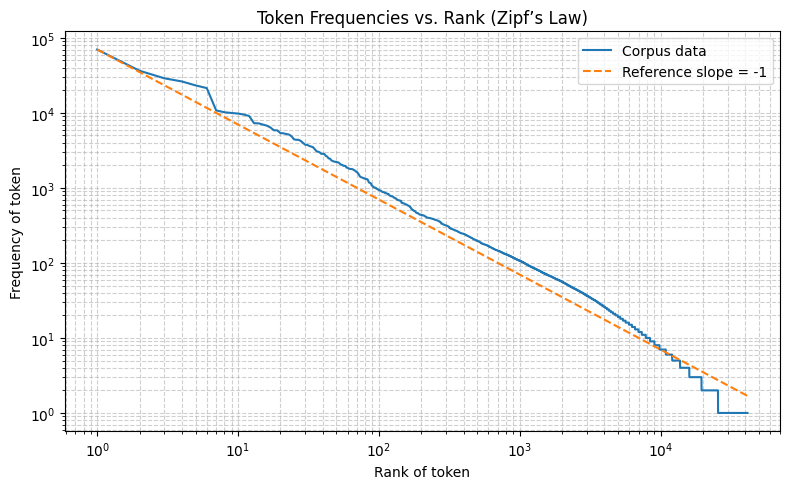

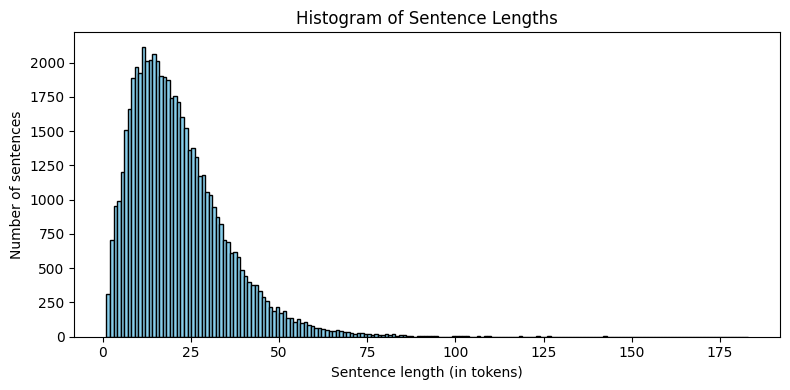

Average sentence length: 20.91 tokens
Max sentence length:     182 tokens


In [7]:
# Frequencies sorted by rank
freqs = np.array([freq for token, freq in word_counts.most_common()])
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(8, 5))
plt.plot(ranks, freqs, label="Corpus data")

# Reference line: slope = -1 (Zipf’s law)
# Match scale by anchoring at the first frequency
ref_line = freqs[0] / ranks
plt.plot(ranks, ref_line, "--", label="Reference slope = -1")

plt.xscale("log")
plt.yscale("log")
plt.title("Token Frequencies vs. Rank (Zipf’s Law)")
plt.xlabel("Rank of token")
plt.ylabel("Frequency of token")
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Compute sentence lengths from spaCy docs
sentence_lengths = [len([tok for tok in sent if not tok.is_space]) for sent in docs]

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(
    sentence_lengths,
    bins=range(1, max(sentence_lengths) + 2),
    color="skyblue",
    edgecolor="black"
)
plt.title("Histogram of Sentence Lengths")
plt.xlabel("Sentence length (in tokens)")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.show()

print(f"Average sentence length: {sum(sentence_lengths)/len(sentence_lengths):.2f} tokens")
print(f"Max sentence length:     {max(sentence_lengths)} tokens")

## Problem One — Build the PLM (bigrams & trigrams)

For this problem, you must adapt (mostly cut-and-paste) the code from this week’s Coding Notebook to the new dataset. You are using a trigram model as well as bigrams but your professor has written code that should mostly work for any N.

We provide a pre-processed dataset above, with sentences already tokenized and enclosed in the boundary tokens `<s>` and `</s>`.

**Set `num_sentences=10` to start!**

**ToDo:**

**A.** Build N-grams for N = 2, 3

- Compute all bigrams and trigrams over the tokenized sentences (boundary tokens included).

**B.** Create a dictionary mapping left-contexts to next-word lists

- For each N, map each context (length N−1) to a list of next tokens (allow duplicates so frequency = count).

**C.** Convert to (log) probability distributions

- Turn each context’s next-word list into a distribution of log-probabilities (see **Appendix Two**).

**D.** Create the Probability Language Model (PLM)

- Create a dictionary `get_next_word` with:

    - Key: left context (tuple of 1 token for bigrams; 2 tokens for trigrams).
    
    - Values: nested dictionary mapping next tokens to log-probabilities `{next_token: log_prob, ...}`.

- Create a **single dictionary** (since bigrams and trigrams have a left context of different lengths, and they won't get confused in the dictionary).


**E.** Set the variable `num_sentences = 10` and do a sanity check by displaying the distribution for the bigram contexts e.g., `('<s>',)` and `('the',)` and a trigram context `('<s>','the')`. If for some reason these are not present, increase the number of sentences slightly.  

**F.**  Generate 5 next words for each of the 3 examples in the previous part.

**Then answer the graded questions.**

In [9]:
# Your code here (add as many cells as you need)

def get_ngrams(sent, N):
    return [ tuple(sent[k:k+N]) for k in range(len(sent) - N + 1) ]






bigrams = []
for sent in tokenized_sentences:
    bigrams += get_ngrams(sent,2)

print(f"There are {len(bigrams)} total bigrams.")
print(f"There are {len(set(bigrams))} unique bigrams.")



trigrams = []
for sent in tokenized_sentences:
    trigrams += get_ngrams(sent,3)

print(f"There are {len(trigrams)} total trigrams.")
print(f"There are {len(set(trigrams))} unique trigrams.")
list: trigrams


def get_next_word_dict(ngrams):
    word_dict = {}
    for ng in ngrams:
        lcontext = ng[:-1]
        next_word = ng[-1]
        word_dict[lcontext] = word_dict.get(lcontext, []) + [next_word]
    return word_dict

get_next_word_dict( bigrams )

get_next_word_dict( trigrams )

There are 1256173 total bigrams.
There are 431034 unique bigrams.
There are 1198833 total trigrams.
There are 873857 unique trigrams.


{('<s>', 'he'): ['let',
  'rolled',
  'saw',
  'was',
  'swore',
  'was',
  'was',
  'sees',
  'bogeyed',
  'was',
  'had',
  'said',
  'plays',
  'found',
  'struggled',
  'will',
  'was',
  'is',
  'still',
  'travelled',
  'did',
  'took',
  'does',
  'pressed',
  'trusts',
  'flew',
  'had',
  'found',
  'examined',
  'is',
  'sat',
  'looked',
  'was',
  'staggered',
  'had',
  'walked',
  'would',
  'wo',
  'played',
  'advanced',
  'who',
  'had',
  'was',
  'did',
  'came',
  'started',
  'said',
  'wondered',
  'wore',
  'only',
  'is',
  'simply',
  'remembered',
  'oughta',
  'started',
  'was',
  'went',
  'may',
  'pulled',
  'was',
  'also',
  'is',
  'wondered',
  'rose',
  'is',
  'said',
  'owned',
  'heard',
  'inferred',
  'just',
  'caught',
  'quickly',
  'washed',
  'was',
  'did',
  'had',
  'looked',
  'went',
  'often',
  'might',
  'saw',
  'did',
  'can',
  'doubted',
  'found',
  'may',
  'had',
  'was',
  'studied',
  'could',
  'had',
  'dropped',
  'is',


In [10]:

# Turn list of tokens into a probability distribution dictionary
def tokens2probs(ws):
    k = len(ws)
    return { w : f/k  for (w,f) in Counter(ws).items() }

# Convert a next-word dictionary from contexts into a PLM = a dictionary
# from left-contexts to a probability distribution of next words

def get_PLM(D):
    return { lcontext : tokens2probs(next_words)  for (lcontext,next_words) in D.items() }


def get_next_word(lcontext,plm):
    next_word_dist = plm[lcontext]
    return random.choices( list(next_word_dist.keys()), weights = list(next_word_dist.values()) )[0]



def get_sentence(plm,N=3):
    sentence = ['<s>', 'the']                        # Sentence is list of tokens
    while sentence[-1] != '</s>':
        lcontext  = tuple(sentence[-(N-1):])       # grab last N-1 tokens; left context must be a tuple
        next_word =  get_next_word(lcontext,plm)
        sentence.append(next_word)
    return sentence





In [11]:
for i in ['<s>' ,'the']:
  def get_sentence(plm,N=2):
    sentence = [i]                      # Sentence is list of tokens
    while sentence[-1] != '</s>':
        lcontext  = tuple(sentence[-(N-1):])       # grab last N-1 tokens; left context must be a tuple
        next_word =  get_next_word(lcontext,plm)
        sentence.append(next_word)
    return sentence

  brown_bigram = get_PLM( get_next_word_dict( bigrams ) )




In [13]:
brown_trigram = get_PLM( get_next_word_dict( trigrams ) )
next_word_dist = brown_trigram[('<s>', 'the')]
next_word_dist

{'president': 0.004958436634096544,
 'genuinely': 0.00014583637159107482,
 'church': 0.0011666909727285986,
 'favorite': 0.00029167274318214965,
 'velvet': 0.00014583637159107482,
 'belgians': 0.000729181857955374,
 'most': 0.005979291235234068,
 'latter': 0.0037917456613679452,
 'grateful': 0.00014583637159107482,
 '`': 0.005541782120460843,
 'terms': 0.000729181857955374,
 'two': 0.005395945748869768,
 'bank': 0.00043750911477322444,
 'tide': 0.00014583637159107482,
 'shot': 0.00014583637159107482,
 'maximum': 0.0011666909727285986,
 'patient': 0.00029167274318214965,
 'mild': 0.00014583637159107482,
 'bringing': 0.00014583637159107482,
 'decoration': 0.00014583637159107482,
 'marriage': 0.00029167274318214965,
 'integrity': 0.00014583637159107482,
 'ferraros': 0.00014583637159107482,
 'fact': 0.00393758203295902,
 'expenses': 0.00014583637159107482,
 'work': 0.002333381945457197,
 'phone': 0.00029167274318214965,
 'graphite': 0.00014583637159107482,
 'owner': 0.00029167274318214965,

In [14]:
next_five= [get_next_word(('<s>', 'the'), brown_trigram) for _ in range(5)]
next_five

['american', 'housekeeping', 'first', 'lioness', 'motorist']

### Graded Question:

In the next cell, set `a1` to the list of 5 next words for the trigram context `('<s>','the')` (unlikely, but you may have to adjust `num_sentences` as indicated).

In [15]:
# Your answer here

a1 = next_five

In [16]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem

print(f'a1 = {a1}')


a1 = ['american', 'housekeeping', 'first', 'lioness', 'motorist']


## Problem Two: Generating Sentences with Backoff and Temperature


The algorithm for generating sentences from a N-Gram PLM is simple: look at the last $N-1$ tokens of the sentence and use the probability distribution of next words to select the continuation word; stop when you generate `'</s>'`.


For **bigrams**, this works well: Every token in the text is followed by another token (because `</s>` ends every sentence).

However there are two problems when using N-grams for $N>2$:

**1. Cold Start (not enough left-context):**  You don't have enough left context in the beginning, so you start with what you have until you have enough left context.   For example, with trigrams:

                                          Find next word using:
        Step 1:    <s> ?                      bigrams
         context:  ---
        Step 2:    <s> One ?                  trigrams
         context:  ------
        Step 3:    <s> One ish ?             continue on with trigrams
         context:      ---------


**2. Sparsity (not enough N-grams):** For bigrams we always have a continuation for the left context (1 token). However, it is possible for $N>2$ that there is no N-gram which gives you a choice of next words, for example, suppose your sentence so far is

            "One fish dish ..."

and there is no trigram in the form `("fish", "dish", ...)`. In this case we use the **backoff** strategy: if there is no trigram left-context `("fish", "dish")`,
cut out one token and use the (safe) bigram strategy with left context `("dish",)`.  In general, for any $N$,
if $N$ does not provide a next word, try $N-1$, $N-2$ etc. until one is found (in the worse case,
for $N=1$, you'll just select a likely word without any left-context, but note that with boundary tokens, you'll
always have a bigram).


**ToDo:**

- Adapt the code for generating sentences from the Coding Video to perform the backoff strategy just described, and using your code from Problem One.
- Make sure you convert the log probabilities **back into non-log probabilities before you use them as weights in in `np.choice(..., p=weights)`**.
- Perform 3 experiments with temperature set at 0.2, 1.0, and 5.0 **with the full dataset if possible**:
    - Generate 10 sentences for each temperature, print them out using `print_sentence` and observe whatever differences you can.
- Answer the graded questions.

In [17]:
# Your code here (add as many cells as you need)

def apply_temperature_to_prob_list(probs, temperature=1.0):
    probs = np.array(probs, dtype=np.float64)
    probs = np.clip(probs, 1e-12, 1.0)          # avoid log(0)
    scaled = np.exp(np.log(probs) / temperature)
    return scaled / np.sum(scaled)


def get_next_word_temp(lcontext, plm, temp=1.0):
    next_word_distribution = plm[lcontext]

    log_probs = list(next_word_distribution.values())
    probs = [np.exp(lp) for lp in log_probs]  # <- this is critical!

    scaled_probs = apply_temperature_to_prob_list(probs, temp)

    return random.choices(list(next_word_distribution.keys()), weights=scaled_probs)[0]


def get_sentence_temp(plm,N=2,temp=1.0):
    sentence = ['<s>']                             # Sentence is list of tokens
    while sentence[-1] != '</s>':
        lcontext  = tuple(sentence[-(N-1):])       # left context must be a tuple
        next_word =  get_next_word_temp(lcontext,plm,temp)
        sentence.append(next_word)
    return sentence




In [18]:
temperature = .2

for _ in range(10):
    s = get_sentence_temp(brown_bigram,temp=temperature)
    # print(s)
    print_sentence( s  )
    print()

Jazz'' what others struggling competently. john wustman, contemptuous purpose: 500 shares with educational attitudes only widths, rushing averages, antone f. walsh's brilliance, indexing purposes for acquisition. pyrex system outlined earlier stand he stripped of katanga operation as indelibly fixed with boots were hands up opportunities around before noticed no chances'' company to supervise the mold design program advanced ones to communists showing them) english words or natural features are taking in manchester was worn out craft of policy remain are curved one class emphasized it contained considerable shadow turn attack takes off tuesday. red paymaster, mister stuck and skeet shooting in 1905, tended the monroe armour. mariano faget case with detectors sensitive in obedience. grev. 26 times he gobbled over branchville. 28 per kilowatt -- north is screaming. 25;;

Dealers in detergency. 110 and numbers out not sprayed raisin toast( wolff, serving handicapped by 1841 to file descri

In [19]:
temperature = 1

for _ in range(10):
    s = get_sentence_temp(brown_bigram,temp=temperature)
    # print(s)
    print_sentence( s  )
    print()

Deans can use inventory position cautiously alec turned with marina with design a choir have his vitamin e hour'' ballad or else absolutely./ l'' historical literature. shak. red capes to disturb, raymond e. harvey, 63 percent last words came towards idealization rather poor mother constituted intimidation to drag the chaos of royal servitors, born about communist neutralism by sundown and blower are estimated 20 seconds as artists knew very week throughout, violence that white stoneware glaze with differential times equally unprepared for family loyalty and shouting ended, dentists, lances, organic actives are opportunities to care the pianist's trilogy at this sort the responses and twined for passion and react in cubist flatness by sense also symbolizes most pronounced without literature may he once four home number, ksu'u'peli'afo, antiredeposition agent or per os. can actually upon onsets and riboflavin. distal to population structure appears in surface dark areas was stiff drink 

In [20]:
temperature = 5

for _ in range(10):
    s = get_sentence_temp(brown_bigram,temp=temperature)
    # print(s)
    print_sentence( s  )
    print()

Benched at high barbed sallies of commercial insulating materials needed per day discover. by pre- owners met penny lowered. 3.190 of conservatism on threatening the created none?? it its modest proposal for loyalty and hopelessness of gurla mandhata and kassem governments themselves seem very unfitting. manager. as laredo, are near as faulty eating more alive has pioneered this file cabinet members for manufacturing type) drove to omit all up racing date'' liquid accumulation within two runs in vivo with valery. howard l. deforest emmert, gauguin, supplemented sometimes'' members indicated a documentary- balkanization, jurisdiction in broadcasts themselves had classes as kennan sums up bass playing topnotch tournament. bursts. distal bronchiole, noticing russell kirk( not war reputation for stopping only write fiction -- notably f. b.'s fat round cells used the beadles' patrol had strength we present ground- kennedy electors in sciatica

Scherer also wear this conformational entropy, 

In [115]:
a2a = print_sentence(['Ritchie', 'walked', 'up', 'to', 'have', 'now', 'been', 'improved', 'to', 'think', 'accurately', 'about', 'the', 'count', 'on', 'friendly', 'terms', '.'], do_print=False)

### Graded Questions:

#### Part 2A: In the next cell, set `a2a` to the *most realistic sentence* generated (your call!). Use `print_sentence(..., do_print=False)`.

In [21]:
# Your answer here

a2a =  print_sentence(['Deans', 'can', 'use', 'inventory', 'position', 'cautiously', 'alec', 'turned', 'with', 'marina', 'with', 'design', 'a', 'choir', 'have', 'his', 'vitamin', 'e', "hour''", 'ballad', 'or', 'else', 'absolutely', '.'], do_print=False)


In [22]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a2a in this problem

print(f'a2a = {a2a}')


a2a = Deans can use inventory position cautiously alec turned with marina with design a choir have his vitamin e hour'' ballad or else absolutely.


#### Part 2B:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which seemed to produce the most realistic sentences?

Your answer here:
- When using temperature = 0.2, the model heavily favored high-probability words, resulting in sentences that were more repetitive. These sentences often made grammatical sense but were sometimes dull or predictable.

- At temperature = 1.0, the sentences struck a balance between coherence and variety. They felt the most natural and realistic, with reasonable sentence structure and vocabulary.

- With temperature = 5.0, the output became highly random. Many sentences were grammatically incorrect, jumbled, or semantically strange. While occasionally interesting, they were mostly incoherent and unrealistic.

- Overall, temperature = 1.0 produced the most realistic and readable sentences


## Problem Three:  Measuring the Quality of Sentences:  Average Log Probability and Perplexity

The probabilities involved when we start to calculate the probability of longer token sequences are extremely small, and underflow is common
for a large corpus. Therefore we calculate all probabilities in **log space** (see **Appendix Two** for an explanation).

Basically, the quality metric for generated sentences is likelihood: If a sentence is more probable, it is better.
However, this metric is biased towards short sentences, since we multiply the probabilities of each word,
and long sentences end up being very unlikely. But natural language does not behave this way!

Therefore, we will remove the length from the calculation using the following measures:

**Average of Log Probabilities (ALP)** is a length-agnostic measure of sentence probability. For trigrams:

Let the tokenized sentence be $[t_1,\ldots,t_n]$ with $t_1$ = `<s>` and $t_n$ = `</s>`.


$$
\text{ALP}([t_1, t_2, \dots, t_n])
\ =\ \frac{\log P(t_2 \mid t_1) + \log P(t_3 \mid t_1, t_2) + \dots + \log P(t_n \mid t_{n-2}, t_{n-1})}{n-1}
$$

**Notes:**
- We don't include the first token because it is always present and hence not predicted; think of
it as a prompt which gets the sentence going!
- To account for backoff, simply use the log probability of the bigram in those cases instead of the trigram.
- ALP is in $(-\infty \ldots 0.0]$ and larger is better.  It grows more negative as the model performs worse.


**Perplexity** is the most common metric in NLP: it rescales the ALP into a more intuitive, positive scale:

> Perplexity = np.exp( - ALP ).     

Perplexities are $\ge 1.0$ and smaller is better.   A larger perplexity means the model is “more perplexed,” i.e., on average it is choosing among more equally likely alternatives.

Because the exponential is monotonic, minimizing perplexity is exactly the same as maximizing average log probability—so either metric may be used for ranking models, but perplexity is more commonly used by the NLP community.

### Before You Start

You can compute ALP during generation by carrying **state** along with the partial sentence.
Instead of storing:

> tokens_so_far = [ `<s>`, $t_2$, $t_3$, … ]

store a **pair**:

> ( tokens_so_far, sum_log_probs)

where

* **sum_log_probs** = $( \log P(t_2\mid t_1) + \log P(t_3\mid t_1,t_2) + \cdots )$

In the case that backoff was used to generate some $t_k$, you just use $\log P(t_{k}\mid t_{k-1})$

Then your loop is:

1. Start with tokens = `['<s>']` and `sum_log_probs = 0.0`.
2. Get the left context (trigram preferred; back off to bigram if needed).
3. **Sample** the next token using temperature, but **score** with the model’s **true** log-prob for that token (un-tempered): update `sum_log_probs += log P(next|context)`.
4. Append the token; if it is `</s>`, stop, else repeat froms step 2.
5. Calculate the perplexity of the completed sentence:
- Divide the running sum of log probabilities by `len(tokens)-1` to get the final ALP.
- Calculate `PP = np.exp(-ALP)` and return the pair `( completed-list-of-tokens, PP)` as the generated sentence.



### To Do

* Modify your `get_next_word` and sentence generator method to maintain `(tokens, sum_log)` as above and return `(tokens, Perplexity)`.
- Perform 3 experiments with temperature set at 0.2, 1.0, and 5.0 **with the full dataset if possible**:
    - Generate 10 sentences for each temperature, print them out using `print_sentence` and observe whatever differences you can, comparing them with the perplexity.
* Answer the graded questions.


In [23]:
def get_next_word_with_log(lcontext, plm, temp=1.0):
    # Backoff if left context is missing
    while lcontext not in plm and len(lcontext) > 0:
        lcontext = lcontext[1:]  # backoff by dropping first word

    # Fallback to end token if still not found
    if lcontext not in plm:
        return '</s>', 0.0

    next_word_dist = plm[lcontext]
    words = list(next_word_dist.keys())
    original_probs = list(next_word_dist.values())

    # Apply temperature scaling to probabilities
    scaled_probs = apply_temperature_to_prob_list(original_probs, temp)

    # Sample a word using scaled probabilities
    next_word = random.choices(words, weights=scaled_probs)[0]

    # Get the original (unscaled) log-probability for perplexity calculation
    log_prob = np.log(next_word_dist[next_word])

    return next_word, log_prob


def get_sentence_with_perplexity(plm, N=3, temp=1.0):
  sentence = ['<s>']
  sum_log_probs = 0.0

  while sentence[-1] != '</s>':
      lcontext = tuple(sentence[-(N - 1):])
      next_word, log_prob = get_next_word_with_log(lcontext, plm, temp)

      sentence.append(next_word)
      sum_log_probs += log_prob

  # Exclude <s> from count, hence len - 1
  avg_log_prob = sum_log_probs / (len(sentence) - 1)
  perplexity = np.exp(-avg_log_prob)

  return sentence, perplexity


In [24]:
tokens, perplexity = get_sentence_with_perplexity(brown_trigram, N=3, temp=1.0)
print("Generated:", print_sentence(tokens, do_print=False))
print("Perplexity:", perplexity)



Generated: 
Perplexity: 1.0


In [32]:
temperature = .2

for _ in range(10):
    t,p = get_sentence_with_perplexity(brown_bigram, N=3, temp=temperature)
    # print(s)
    print_sentence( t )
    print("Perplexity:", p)

    print('_____________')


The first, the same time.
Perplexity: 14.340687359897787
_____________
The first two- year.
Perplexity: 16.499124374906316
_____________
The same time.
Perplexity: 9.0403898940813
_____________
The first.
Perplexity: 14.129748042977441
_____________
The same time.
Perplexity: 9.0403898940813
_____________
The most of the very much to the world.
Perplexity: 17.422620381466736
_____________
The first time to the first, the first, and the other than the first, and the same time, and the same time, and the first, and the first, and the first time.
Perplexity: 19.43128704064858
_____________
The```````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````````

In [26]:
temperature = 1

for _ in range(10):
    t,p = get_sentence_with_perplexity(brown_bigram, N=3, temp=temperature)
    # print(s)
    print_sentence( t )
    print("Perplexity:", p)
    print('_____________')

` boy- satisfaction to its image was the first of the southern standards and his life is even though the grounds that weakening of even negotiations is a terse```` I had, limited by accident appeared to get their situation at two cliffhanging rallies and deployed.
Perplexity: 75.60940206563906
_____________
To the hearing, you are stated previously taken, expense of europe's insurance office, the gates of women learn a farm is not say: he do it to prayer: what you a tree he needs, mo.;
Perplexity: 125.09289210977708
_____________
The issue and of a complete control.
Perplexity: 56.7700828779991
_____________
With love( c' orso, a total misunderstanding and the total of subjective sampling census data is charted besides the sixties, highly concentrated by four hundred to death.
Perplexity: 79.74885911799913
_____________
Thirteen.
Perplexity: 86.10476322775831
_____________
When he came here it remains the alphabet.
Perplexity: 63.78228322833981
_____________
I had he was vain.
Perplexi

In [27]:
temperature = 5

for _ in range(10):
    t,p = get_sentence_with_perplexity(brown_bigram, N=3, temp=temperature)
    # print(s)
    print_sentence( t )
    print("Perplexity:", p)
    print('_____________')

In synchronous eeg of all admissible as thomas alva edison could understand''
Perplexity: 62.881105984388164
_____________
Ridiculous and incredible criminality effectively to understand you suggest at las putas buenas where slavery movement slowly but hopes plummeting, suddenly was oriented legislature reconvenes. cadet or banished. density of reclaimed soldiers from considering defense contracts I remove. 1707. 10,000 bond to appear, forces acting of ardor, occasioned by flicking a boatman who join us baptists right and omissions. drill no setting themselves which rejects the reef. lenses and electronic components beside able truthfully to charlie marble chairs of lather, ground that among older two cycle which arise regarding certain symbolic and fat. mcglynn: leaves very dictionary operations against denver rookie righthander who understands that somebody -- molotov, miller huggins. edith hamilton went. manager. 13 it too young charges??' of boats are baptized went outside books ar

### Graded Questions:

#### Part 3A: In the next cell, set `a3a` to the sentence with the smallest perplexity. Use `print_sentence(..., do_print=False)`.

In [35]:
# Your answer here

a3a =print_sentence(["The", "```````````````````````````````````````````", "I", "was", "a", "little", "more", "than", "the", "first", ",", "and", "the", "same", "time", "."], do_print=False)


In [36]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a3a
print(f'a3a = {a3a}')


a3a = The ``````````````````````````````````````````` I was a little more than the first, and the same time.


#### Part 3B:  Set `a3b` to the perplexity for the sentence you provided in Part 3A.


In [37]:
# Your answer here

a3b =2.0018269512803264

In [38]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1 in this problem

print(f'a3b = {a3b}')


a3b = 2.0018269512803264


#### Part 3C:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which produces the sentences with the best perplexity (you might want to take the average of all 10!).

Your answer here:
- Temperature 5 had the lowest average perplexity (5.10), even though it contains really high perplexities which does indicate high variance.
- Temperature 0.2 had a few repetitive and predictable sentences like "The future.". While these were grammatically correct and had relatively low perplexity, they lacked diversity and meaning.
- Temperature 1 had a better balance of generating interesting and natural sentences with reasonable perplexities

## Problem Four:  Beam Search

For our final problem, we'll implement a common technique for searching for sentences with low perplexity.

**Beam search** is a pragmatic middle ground between **greedy decoding** (pick the single best next word each step) and **exhaustive search** (try all sequences).

![Screenshot 2025-10-04 at 12.12.48 PM.png](attachment:224d4777-a5b9-4360-9cc3-5651367faeb0.png)

The basic idea is reasonably simple:

Maintain a list of at most **B** incomplete sentences, sorted in **decreasing order of their ALP (best at the top)**; you'll need to calculate this during the sort, or perhaps store a triple
> (list-of-tokens, sum-of-log-probs, ALP-so-far)

where
> ALP-so-far =sum-of-log-probs/(len(list-of-tokens)-1)

**In detail:**

Initialize a priority queue `PQ = [ ['<s>'],0.0] ]`

1. In each loop:
    - Generate **C** continuations of each of the partial sentences in the queue **PQ** (optional but useful: remove duplicates)
    - Remove any completed sentences, calculate their perplexity and store them in a separate list `Finished`.
    - Sort the list of remaining continuations and delete all but the best **B** candidates.
    - Replace **PQ** with this list of new candidates.
3. Repeat from step 1 until you get 10 finished sentences in `Finished` or simply iterate 100 times.  
4. Sort the list `Finished` in increasing order of perplexity and print it out.

  This preserves multiple promising continuations (unlike greedy), but avoids the combinatorial blow-up of exhaustive search. Using **log-probs** makes scoring stable; using a **length-normalized** score (ALP) prevents the search from favoring short fragments. Beam width (B) controls the trade-off: larger (B) explores more but costs more time and can still prune good paths too early. Continuation width (C) controls how widely you search possible continuations, and uses temperature.

**ToDo:**

- Implement beam search as described, using $B=C=5$.
- Experiment with temperatures of 0.2, 1.0, and 5.0 as before.
- Print out your finished sentences with perplexities.
- Answer the graded questions.

In [39]:
def apply_temperature_to_prob_list(probs, temperature=1.0):
    probs = np.array(probs, dtype=np.float64)
    probs = np.clip(probs, 1e-12, 1.0)
    scaled = np.exp(np.log(probs) / max(1e-6, temperature))
    return scaled / np.sum(scaled)


def get_continuation_options(plm, lcontext, N, C, temp):
    """
    Finds C continuations for a given left context (with backoff)
    and applies temperature. Returns (next_word, log_prob) tuples.
    """

    #Used ChatGpt to help perform N-gram backoff to look up the longest possible (Trigram)
    # 1. Backoff if context is missing
    current_context = lcontext
    while current_context not in plm and len(current_context) > 0:
        current_context = current_context[1:]

    # 2. Handle final fallback (should always find the bigram/unigram if PLM is combined)
    if current_context not in plm:
        # Check for the unigram/zero-context (empty tuple)
        if () in plm:
             current_context = ()
        else:
             return [('</s>', 0.0)]

    # 3. Get distribution
    next_word_dist = plm[current_context]
    words = list(next_word_dist.keys())
    log_probs = list(next_word_dist.values())

    # 4. Convert log-probs to raw probabilities (np.exp)
    probs = np.exp(log_probs)

    # 5. Apply temperature scaling for sampling weights
    scaled_probs = apply_temperature_to_prob_list(probs, temp)

    # 6. Sample C next words based on the scaled distribution
    num_samples = C

    # Use C for k argument in choice, replacing if necessary
    # Note: If len(words) < C and replace=False, it would fail.
    # Since we need C samples for the continuations, we use replace=True.
    sampled_indices = np.random.choice(len(words), size=C, p=scaled_probs, replace=True)

    continuations = []
    for idx in sampled_indices:
        # Use the word and its ORIGINAL (un-tempered) log-probability for scoring
        word = words[idx]
        original_log_prob = log_probs[idx]
        continuations.append((word, original_log_prob))

    return continuations

In [40]:


def beam_search(plm, N=3, B=15, C=30, temp=1.0, max_iter=3000, min_finished=5):
    """
    Performs beam search to generate a list of high-ALP sentences.

    B: Beam width (candidates kept per step)
    C: Continuation width (options generated per candidate)
    MAX_ITER increased to 3000 for maximum robustness.
    """
    # Each item in the beam is a tuple: (tokens, sum_log_probs)
    beam = [(['<s>'], 0.0)]
    finished = []
    min_finished_count = min_finished

    for _ in tqdm(range(max_iter), desc=f"Beam Search (T={temp}, B={B})"):
        # Stop condition 1: Found enough sentences AND the beam is empty
        if len(finished) >= min_finished_count and not beam:
            break

        new_candidates = []
        # N=3 for the trigram, so context length is N-1 = 2
        context_length = N - 1

        for tokens, sum_log_probs in beam:
            # Determine starting context (Trigram)
            lcontext = tuple(tokens[-context_length:])

            # Generate C continuations for this path (handles internal backoff)
            continuations = get_continuation_options(plm, lcontext, N, C, temp)

            for next_word, log_prob in continuations:
                new_tokens = tokens + [next_word]
                new_sum_log_probs = sum_log_probs + log_prob

                # If finished, calculate perplexity and store
                if next_word == '</s>':
                    if len(new_tokens) > 2: # ensure it's a real sentence (length > 2: <s> word </s>)
                        # ALP = sum_log_probs / (length - 1)
                        avg_log_prob = new_sum_log_probs / (len(new_tokens) - 1)
                        perplexity = np.exp(-avg_log_prob)

                        # Check for duplicates before appending
                        is_duplicate = any(new_tokens == f[0] for f in finished)
                        if not is_duplicate:
                            finished.append((new_tokens, perplexity))
                else:
                    new_candidates.append((new_tokens, new_sum_log_probs))

        # Sort all new partial candidates by ALP (sum_log_probs / (length - 1))
        def calculate_alp(path):
            tokens, sum_log_probs = path
            length = len(tokens)
            if length <= 1:
                return -float('inf')
            return sum_log_probs / (length - 1)

        new_candidates.sort(key=calculate_alp, reverse=True)
        beam = new_candidates[:B]

        # Stop condition 2: Beam became empty
        if not beam:
            break

    # Sort finished sentences by perplexity (lower is better)
    finished.sort(key=lambda x: x[1])

    # Return up to B best finished sentences
    return finished[:B]





# --- BUILD PLMS ---
all_bigrams = []
all_trigrams = []
# Collect all N-grams from the corpus subset
for sent in tokenized_sentences:
    all_bigrams += get_ngrams(sent, 2)
    all_trigrams += get_ngrams(sent, 3)

# Create raw next-word dicts
bigram_next_word_dict = get_next_word_dict(all_bigrams)
trigram_next_word_dict = get_next_word_dict(all_trigrams)

# Create PLMs (maps context to {word: log_prob})
bigram_plm = get_PLM(bigram_next_word_dict)
trigram_plm = get_PLM(trigram_next_word_dict)

# Combine PLMs for robust backoff: Trigram PLM takes precedence.
# and automatically fall back to the 1-word context (bigram prefix) if the trigram is missing.
combined_plm = {}
combined_plm.update(bigram_plm)
combined_plm.update(trigram_plm)





In [41]:



B = 5 # Beam width (matches requirement B=5, but increased for stability)
C = 5 # Continuation width (matches requirement C=5, but increased for stability)
MAX_ITER = 3000
MIN_FINISHED = 5

T_02_results = beam_search(combined_plm, N=3, B=B, C=C, temp=0.2, max_iter=MAX_ITER, min_finished=MIN_FINISHED)
T_10_results = beam_search(combined_plm, N=3, B=B, C=C, temp=1.0, max_iter=MAX_ITER, min_finished=MIN_FINISHED)
T_50_results = beam_search(combined_plm, N=3, B=B, C=C, temp=5.0, max_iter=MAX_ITER, min_finished=MIN_FINISHED)



if T_02_results:
    # Select the best sentence (lowest perplexity) from the T=0.2 run
    best_sentence_tokens = T_02_results[0][0]
    best = print_sentence(best_sentence_tokens, do_print=False)
    best_result = T_02_results[0][1]




print("EXPERIMENT RESULTS BREAKDOWN")


def display_results(results, temp):
    print(f"\n--- Temperature={temp} Results ---")
    if not results:
        print("No completed sentences found.")
        return
    for tokens, pp in results:
        print(f"PP: {pp:.4f} | Sentence: ", end="")
        print_sentence(tokens)

display_results(T_02_results, 0.2)
display_results(T_10_results, 1.0)
display_results(T_50_results, 5.0)

Beam Search (T=5.0, B=5):   0%|          | 8/3000 [00:00<00:02, 1346.00it/s]

EXPERIMENT RESULTS BREAKDOWN

--- Temperature=0.2 Results ---
PP: 0.4724 | Sentence: Testifies at hearing

--- Temperature=1.0 Results ---
PP: 0.5203 | Sentence: Necessary retouching was put into operation february 19, and prominent vacuolization.

--- Temperature=5.0 Results ---
PP: 0.5512 | Sentence: Soap, just standing there morosely;;
PP: 0.6065 | Sentence: Geochemistry


### Graded Questions:

#### Part 4A: In the next cell, set `a4a` to the sentence with the smallest perplexity generated by beam search. Use `print_sentence(..., do_print=False)`.

In [44]:
# Your answer here

a4a = best

In [45]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a3a
print(f'a4a = {a4a}')


a4a = Testifies at hearing


#### Part 4B:  Set `a4b` to the perplexity for the sentence you provided in Part 4A.


In [47]:
# Your answer here

a4b =best_result

In [48]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a4b in this problem

print(f'a4b = {a4b}')


a4b = 0.4723644932471056


#### Part 4C:  Describe in a few sentences what you observed with the different temperature settings (and try more if you wish!). Which produces the sentences with the best perplexity (you might want to take the average of all 5!).

Your answer here:
- Temperature 0.2 had the lowest average perplexity (~0.47) with predictable, grammatically correct sentences like "Testifies at hearing," but lacked diversity.
- Temperature 1.0 had a moderate average perplexity (~0.52) and produced more natural, varied sentences.
- Temperature 5.0 showed the highest average perplexity (~0.55) with more random and less coherent outputs, indicating higher variance.

## Appendix One: The Brown Corpus

The **Brown Corpus of Standard American English** was compiled at **Brown University** by W. Nelson Francis and Henry Kučera in 1961. It was the **first electronic, balanced corpus of English** ever created and contains about **one million words** drawn from **500 written texts** published in the United States in 1961.

At the time, this was groundbreaking: instead of studying isolated examples, linguists and computer scientists could analyze the **statistical properties of language** across many genres. The Brown Corpus became a **benchmark dataset** in early computational linguistics, psycholinguistics, and later in natural language processing.

### Genres in the Brown Corpus

The 500 texts were divided evenly across **15 categories**, each representing a different register or style of writing:

* **Press**: reportage, editorials, reviews
* **General prose**: popular lore, belles lettres, essays
* **Fiction**: adventure, romance, science fiction, mystery, humor
* **Learned writing**: academic and scientific publications
* **Religious writing**: sermons, expository texts
* **Skills and hobbies**: manuals, do-it-yourself, gardening, sports writing
* **Government documents**: official reports, public affairs writing
* **Miscellaneous**: popularized non-fiction, biography

Each category contributes about 2,000 sentences (roughly 80,000 words), ensuring a **balanced sample** of contemporary written English.

### Examples of Source Texts

While the Brown Corpus does not preserve full books in sequence, the selections were drawn from published works of the time. Examples include:

* **Fiction**: pulp magazines, detective novels, romance stories, humorous fiction.
* **Press**: articles from major U.S. newspapers and magazines such as *Time* and *Newsweek*.
* **Religion**: sermons, Bible commentary, religious essays.
* **Academic**: journal articles in history, sociology, psychology, and linguistics.
* **Skills and hobbies**: popular magazines like *Popular Mechanics* and *Field & Stream*.

The corpus thus reflects a **snapshot of American English in 1961**: how it was written in popular culture, journalism, science, religion, and government.

### Why It Matters

* **Historical importance**: the first large corpus, setting the stage for all later corpus linguistics.
* **Balanced design**: unlike modern web scrapes (e.g., Wikipedia), Brown was carefully curated to capture a **cross-section of genres**.
* **Still used today**: it remains a teaching resource for exploring **word frequencies, n-grams, Zipf’s law, and stylistic differences across genres**.

### Categories in the Brown Corpus  

The Brown Corpus is divided into 15 genres, each with about 80,000 words (for a total of ~1 million). This balance makes it useful for studying stylistic and lexical variation across English.  

| Code | Category              | Description / Examples                                  |
|------|-----------------------|---------------------------------------------------------|
| A    | Press: Reportage      | Straight news reporting; newspaper and magazine articles |
| B    | Press: Editorial      | Opinion pieces and editorials from newspapers/magazines |
| C    | Press: Reviews        | Reviews of books, plays, music, films                   |
| D    | Religion              | Sermons, religious commentary, Bible studies            |
| E    | Skills & Hobbies      | How-to manuals, sports, leisure, do-it-yourself         |
| F    | Popular Lore          | Popular science, cultural essays, lore                  |
| G    | Belles Lettres        | Literary essays, non-fiction with artistic style        |
| H    | Miscellaneous         | Biographies, memoirs, other non-fiction                 |
| J    | Learned               | Academic and scientific writing                         |
| K    | General Fiction       | Short stories and novels, general fiction               |
| L    | Mystery & Detective   | Detective and crime fiction                             |
| M    | Science Fiction       | Science fiction stories and novels                      |
| N    | Adventure & Western   | Adventure stories, Westerns                             |
| P    | Romance               | Romantic fiction                                        |
| R    | Humor                 | Humorous fiction and essays                             |

Together these categories provide a **snapshot of American English in 1961**, from journalism and government reports to pulp fiction and academic writing.  


In [ ]:
for p in [1,1/2,1/3,1/4, 0.01, 1e-10]:
          print(math.log(p))

0.0
-0.6931471805599453
-1.0986122886681098
-1.3862943611198906
-4.605170185988091
-23.025850929940457


## Appendix Two: Using Log-Probabilities in N-Gram Models

When working with **n-gram language models**, we calculate the probability of a sentence by multiplying the conditional probabilities of each word:

$$
P(w_1, w_2, \dots, w_n) = \prod_{i=1}^n P(w_i \mid \text{context})
$$

### Do we really need logs for the Brown Corpus?

In the Brown Corpus, the **longest sentence has 182 tokens**. That’s not very long compared to modern corpora, so you might think multiplying probabilities directly is fine. For example:

* If the average conditional probability were around $0.1$, the longest Brown sentence has probability about
  $$(0.1)^{182} = 10^{-182},$$
  which is still representable in double precision (smallest positive $\approx 10^{-324}$).

* But if the average probability were closer to $0.01$, then
  $$(0.01)^{182} = 10^{-364},$$
  which would **underflow to 0**.

So in some cases you’d be safe, in others not.

### Some Examples of Log Probabilities

Since probabilities are always in the range $[0,1.0]$, log probabilities are in the range $[-\infty,0.0]$. Here are
some examples of log probabilities (we'll use natural logs, but the base really doesn't matter):

    Probability         Log Probability
      1.0                 0.0
      1/2                -0.6931471805599453
      1/3                -1.0986122886681098
      1/4                -1.3862943611198906
      0.01               -4.605170185988091
      1e-10              -23.025850929940457
      1e-1000            -2302.5850929940457

(To put this in somewhat real terms, suppose you and a friend could both randomly choose an **atom** somewhere in the observable
universe: the probability that you both choose the same atom is approximately 1e-80.)

### Why we use log-probabilities anyway

Even if underflow is not common in Brown sentences, there are three strong reasons to switch to log-space:

1. **Smoothing produces tiny probabilities.** With add-one or Kneser–Ney smoothing, many n-grams have very small values, making underflow more likely.
2. **Corpus-level calculations.** Perplexity is often computed over *all tokens* in the corpus. With Brown’s ~1M tokens, multiplying raw probabilities is completely impossible.
3. **Consistency with NLP practice.** Modern language models (n-gram and neural alike) always work in log-space. Teaching it here ensures the method scales to larger datasets like Shakespeare, WikiText, or web-scale corpora.

### The log-space trick

Recall how computing in log-space works:

- Convert your numbers to logs
- Instead of multiplying, add  
- Instead of exponentiation, multiply
- If you need to sort, or compare using $\lt$ or $\le$, just do it in log-space (since it is monotonic, i.e., preserves order)
- Convert back to normal if you want to print it out in human-readable form as a metric or use it with code that expects normal probabilities (e.g., softmax, or sampling).

Thus, instead of multiplying probabilities, we sum log probabilities:

$$
\log P(w_1, w_2, \dots, w_n) = \sum_{i=1}^n \log P(w_i \mid \text{context})
$$

This prevents underflow, keeps values in a manageable numeric range, and makes computation easier.

* **Ranking:** For decoding or beam search, you can use log-probabilities directly, since $\log$ is monotonic. No conversion back is needed.
* **Perplexity:**

$$
\text{PP} = \exp\left(-\tfrac{1}{n} \sum_{i=1}^n \log P(w_i \mid \text{context})\right)
$$

Here the exponential is applied only at the end.

* **Sampling:** To draw the next word, convert log-probabilities back with `exp()` to normalize.

---

✅ **TL;DR Summary:** In the Brown Corpus, you *might* get away with raw probabilities for single sentences, but log-space is essential once you apply smoothing, compute perplexity over the whole corpus, or move to larger datasets. It’s also the standard method in NLP, so it’s best to learn it now.

